Plot distance-binned CRP curves using categorical features (e.g., emotion tags).

Update `category_features_path` or `feature_column` to explore other categorical features.

`plot_cat_crp` handles the distance conversion and uses fixed bins for same vs different categories.


In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np

from jaxcmr.analyses.distcrp import plot_cat_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/CohenKahana2022_noELI.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['session'] == 1"
category_features_path = "data/emotion_features_7col.npy"
feature_column = 6
feature_label = "Emotionality"


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
category_features = np.load(os.path.join(project_root, category_features_path))


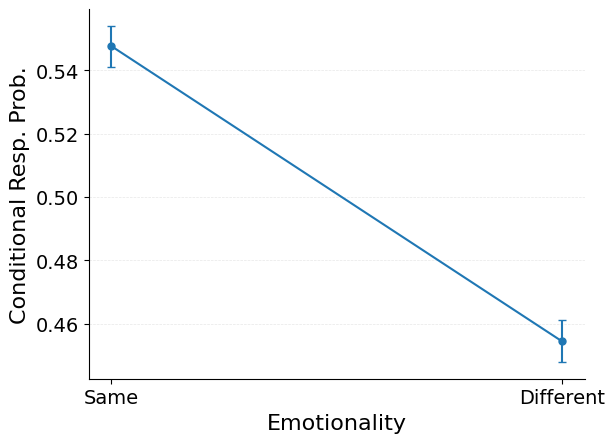

In [4]:
axis = plot_cat_crp(
    datasets=data,
    trial_masks=trial_mask,
    features=category_features,
    feature_column=feature_column,
    feature_label=feature_label.title(),
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)
